# Experiment 1.1: Evolutionary Adversarial Reprogramming of Growing Neural Cellular Automata

This notebook contains a head-to-head comparison between Evolved (CMA-ES) and Backprop (Adam) optimization strategies, operating under an identical 30-minute wall-clock budget. 

## Setup and Utilities

In [1]:
# Colab GPU check

import torch
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

Tesla T4


In [2]:
# Use legacy keras

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [ ]:
#@title Imports and Notebook Utilities
%tensorflow_version 2.x

import io
import PIL.Image, PIL.ImageDraw
import base64
import zipfile
import json
import requests
import numpy as np
import matplotlib.pylab as pl
import glob
import tensorflow as tf
from IPython.display import Image, HTML, clear_output
import tqdm

import os
os.environ['FFMPEG_BINARY'] = 'ffmpeg'
import moviepy.editor as mvp
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
clear_output()

def np2pil(a):
  if a.dtype in [np.float32, np.float64]:
    a = np.uint8(np.clip(a, 0, 1)*255)
  return PIL.Image.fromarray(a)

def imwrite(f, a, fmt=None):
  a = np.asarray(a)
  if isinstance(f, str):
    fmt = f.rsplit('.', 1)[-1].lower()
    if fmt == 'jpg':
      fmt = 'jpeg'
    f = open(f, 'wb')
  np2pil(a).save(f, fmt, quality=95)

def imencode(a, fmt='jpeg'):
  a = np.asarray(a)
  if len(a.shape) == 3 and a.shape[-1] == 4:
    fmt = 'png'
  f = io.BytesIO()
  imwrite(f, a, fmt)
  return f.getvalue()

def im2url(a, fmt='jpeg'):
  encoded = imencode(a, fmt)
  base64_byte_string = base64.b64encode(encoded).decode('ascii')
  return 'data:image/' + fmt.upper() + ';base64,' + base64_byte_string

def imshow(a, fmt='jpeg'):
  display(Image(data=imencode(a, fmt)))

def tile2d(a, w=None):
  a = np.asarray(a)
  if w is None:
    w = int(np.ceil(np.sqrt(len(a))))
  th, tw = a.shape[1:3]
  pad = (w-len(a))%w
  a = np.pad(a, [(0, pad)]+[(0, 0)]*(a.ndim-1), 'constant')
  h = len(a)//w
  a = a.reshape([h, w]+list(a.shape[1:]))
  a = np.rollaxis(a, 2, 1).reshape([th*h, tw*w]+list(a.shape[4:]))
  return a

def zoom(img, scale=4):
  img = np.repeat(img, scale, 0)
  img = np.repeat(img, scale, 1)
  return img


In [6]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_SIZE = 40
BATCH_SIZE = 8
POOL_SIZE = 1024
CELL_FIRE_RATE = 0.5

EXPERIMENT_TYPE = "Regenerating" #@param ["Persistent", "Regenerating"]
EXPERIMENT_MAP = {"Persistent":0, "Regenerating":1}
EXPERIMENT_N = EXPERIMENT_MAP[EXPERIMENT_TYPE]
LOSS_THRESHOLD = -2.5

DAMAGE_N = [0, 3][EXPERIMENT_N]  # Number of patterns to damage in a batch

In [7]:
#@title CA Model and Utilities
from tensorflow.keras.layers import Conv2D

def load_image(url, max_size=TARGET_SIZE):
  r = requests.get(url)
  img = PIL.Image.open(io.BytesIO(r.content))
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img)/255.0
  img[..., :3] *= img[..., 3:]
  return img

def to_rgba(x):
  return x[..., :4]

def to_alpha(x):
  return tf.clip_by_value(x[..., 3:4], 0.0, 1.0)

def to_rgb(x):
  rgb, a = x[..., :3], to_alpha(x)
  return 1.0-a+rgb

def get_living_mask(x):
  alpha = x[:, :, :, 3:4]
  return tf.nn.max_pool2d(alpha, 3, [1, 1, 1, 1], 'SAME') > 0.1

def make_seed(size, n=1):
  x = np.zeros([n, size, size, CHANNEL_N], np.float32)
  x[:, size//2, size//2, 3:] = 1.0
  return x

class CAModel(tf.keras.Model):
  def __init__(self, channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE):
    super().__init__()
    self.channel_n = channel_n
    self.fire_rate = fire_rate
    self.dmodel = tf.keras.Sequential([
          Conv2D(128, 1, activation=tf.nn.relu),
          Conv2D(self.channel_n, 1, activation=None,
              kernel_initializer=tf.zeros_initializer),
    ])
    self(tf.zeros([1, 3, 3, channel_n]))

  @tf.function
  def perceive(self, x, angle=0.0):
    identify = np.float32([0, 1, 0])
    identify = np.outer(identify, identify)
    dx = np.outer([1, 2, 1], [-1, 0, 1]) / 8.0
    dy = dx.T
    c, s = tf.cos(angle), tf.sin(angle)
    kernel = tf.stack([identify, c*dx-s*dy, s*dx+c*dy], -1)[:, :, None, :]
    kernel = tf.repeat(kernel, self.channel_n, 2)
    y = tf.nn.depthwise_conv2d(x, kernel, [1, 1, 1, 1], 'SAME')
    return y

  @tf.function
  def call(self, x, fire_rate=None, angle=0.0, step_size=1.0):
    pre_life_mask = get_living_mask(x)
    y = self.perceive(x, angle)
    dx = self.dmodel(y)*step_size
    if fire_rate is None:
      fire_rate = self.fire_rate
    update_mask = tf.random.uniform(tf.shape(x[:, :, :, :1])) <= fire_rate
    x += dx * tf.cast(update_mask, tf.float32)
    post_life_mask = get_living_mask(x)
    life_mask = pre_life_mask & post_life_mask
    return x * tf.cast(life_mask, tf.float32)


In [8]:
#@title Train Utilities (SamplePool, Damage)
class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

@tf.function
def make_circle_masks(n, h, w):
  x = tf.linspace(-1.0, 1.0, w)[None, None, :]
  y = tf.linspace(-1.0, 1.0, h)[None, :, None]
  center = tf.random.uniform([2, n, 1, 1], -0.5, 0.5)
  r = tf.random.uniform([n, 1, 1], 0.1, 0.4)
  x, y = (x-center[0])/r, (y-center[1])/r
  mask = tf.cast(x*x+y*y < 1.0, tf.float32)
  return mask


In [9]:
!wget -O models.zip 'https://github.com/google-research/self-organising-systems/blob/master/assets/growing_ca/models.zip?raw=true'
!unzip -oq models.zip

def get_model(emoji='🦎', fire_rate=0.5, use_pool=1, damage_n=3, run=0,
              prefix='models/', output='model'):
  path = prefix
  assert fire_rate in [0.5, 1.0]
  if fire_rate==0.5:
    path += 'use_sample_pool_%d damage_n_%d '%(use_pool, damage_n)
  elif fire_rate==1.0:
    path += 'fire_rate_1.0 '
  code = hex(ord(emoji))[2:].upper()
  path += 'target_emoji_%s run_index_%d/08000'%(code, run)
  if output == 'model':
    ca = CAModel(channel_n=16, fire_rate=fire_rate)
    ca.load_weights(path)
    return ca
  elif output == 'json':
    return open(path+'.json', 'r').read()


--2026-06-14 17:25:48--  https://github.com/google-research/self-organising-systems/blob/master/assets/growing_ca/models.zip?raw=true
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/google-research/self-organising-systems/raw/refs/heads/master/assets/growing_ca/models.zip [following]
--2026-06-14 17:25:49--  https://github.com/google-research/self-organising-systems/raw/refs/heads/master/assets/growing_ca/models.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/assets/growing_ca/models.zip [following]
--2026-06-14 17:25:49--  https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/assets/growing_ca/models.zip
Resolving raw.githubusercontent.com (raw.gi

--2026-06-14 17:25:50--  https://github.com/google-research/self-organising-systems/blob/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip?raw=true
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/google-research/self-organising-systems/raw/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip [following]
--2026-06-14 17:25:51--  https://github.com/google-research/self-organising-systems/raw/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip [following]
--2026-06-14 17:25:51--  https://raw.githubus

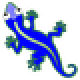

In [10]:
!wget -O growing_ca_target_images.zip 'https://github.com/google-research/self-organising-systems/blob/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip?raw=true'
!unzip -oq "growing_ca_target_images.zip" -d "target_pics"

def load_image_from_file(fp, max_size=TARGET_SIZE):
  img = PIL.Image.open(fp)
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img)/255.0
  img[..., :3] *= img[..., 3:]
  return img

pic_prefix = "target_pics/"
target_map = {
    "liz_no_tail": pic_prefix + "lizard_no_tail.png",
    "lizard_no_leg": pic_prefix + "lizard_no_leg.png",
    "lizard_no_head": pic_prefix + "lizard_no_head.png",
    "lizard_no_arm": pic_prefix + "lizard_no_arm.png",
    "lizard_red": pic_prefix + "lizard_red.png",
    "lizard_blue": pic_prefix + "lizard_blue.png"}

target_label = 'lizard_blue'
target_img = load_image_from_file(target_map[target_label])
print(f"Target ({target_label}) Loaded.")
imshow(zoom(to_rgb(target_img), 2), fmt='png')


## Shared Setup & Helpers (Metrics, Target, Seeds)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.5 MB/s eta 0:00:00


  warnings.warn(

  warnings.warn(msg)



Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 167MB/s]  


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Healthy Lizard Seed Ready:


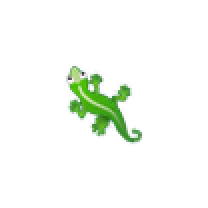

loss0 (empty seed): 0.021845243871212006


In [ ]:
#@title Shared setup & helpers (seed, NCA, eval, metrics)
import time
!pip install -q cma lpips
import cma
import lpips
import torch

# ---- METRICS: SSIM, LPIPS, Fourier ----
fourier_use_parts = False

def compute_ssim(img1, img2):
    img1_tf = tf.convert_to_tensor(img1[None, ...], dtype=tf.float32)
    img2_tf = tf.convert_to_tensor(img2[None, ...], dtype=tf.float32)
    return float(tf.image.ssim(img1_tf, img2_tf, max_val=1.0).numpy())

loss_fn_alex = lpips.LPIPS(net='alex').cuda() if torch.cuda.is_available() else lpips.LPIPS(net='alex')

def compute_lpips(img1, img2):
    t1 = torch.tensor(img1.transpose(2,0,1)[None, ...], dtype=torch.float32)
    t2 = torch.tensor(img2.transpose(2,0,1)[None, ...], dtype=torch.float32)
    t1 = t1 * 2.0 - 1.0
    t2 = t2 * 2.0 - 1.0
    if torch.cuda.is_available():
        t1, t2 = t1.cuda(), t2.cuda()
    with torch.no_grad():
        d = loss_fn_alex(t1, t2)
    return float(d.item())

def compute_fourier_diff(img1, img2):
    gray1 = np.mean(img1, axis=-1)
    gray2 = np.mean(img2, axis=-1)
    f1 = np.fft.fft2(gray1)
    f2 = np.fft.fft2(gray2)
    mag1 = np.log1p(np.abs(f1))
    mag2 = np.log1p(np.abs(f2))
    return float(np.mean(np.abs(mag1 - mag2)))

def compute_fourier_diff_parts(img1, img2, n_parts=2):
    h, w = img1.shape[:2]
    ph, pw = h // n_parts, w // n_parts
    diffs = []
    for i in range(n_parts):
        for j in range(n_parts):
            block1 = img1[i*ph:(i+1)*ph, j*pw:(j+1)*pw]
            block2 = img2[i*ph:(i+1)*ph, j*pw:(j+1)*pw]
            diffs.append(compute_fourier_diff(block1, block2))
    return float(np.mean(diffs))

def compute_all_metrics(img_target, img_grown):
    ssim_val = compute_ssim(img_target, img_grown)
    lpips_val = compute_lpips(img_target, img_grown)
    if fourier_use_parts:
        fourier_val = compute_fourier_diff_parts(img_target, img_grown, n_parts=2)
    else:
        fourier_val = compute_fourier_diff(img_target, img_grown)
    return ssim_val, lpips_val, fourier_val

# ---- Head-to-head budget setup ----
TRAIN_SECONDS = 30 * 60      # wall-clock budget per method
RENDER_STEPS  = 120          # NCA steps used when growing an image for display
EVAL_STEPS    = 96           # NCA steps used for the "grown-image loss" metric
EVAL_RUNS     = 4            # stochastic renders averaged for that metric

TARGET_PADDING = 32
p = TARGET_PADDING
pad_target = tf.pad(target_img, [(p, p), (p, p), (0, 0)])
h, w = pad_target.shape[:2]

seed = np.zeros([h, w, CHANNEL_N], np.float32)
seed[h // 2, w // 2, 3:] = 1.0

def loss_f(x):
    return tf.reduce_mean(tf.square(to_rgba(x) - pad_target), [-2, -3, -1])

target_emoji = '🦎'
ca = get_model(emoji=target_emoji)

x0_seed = seed[None, ...]
for _ in tf.range(200):
    x0_seed = ca(x0_seed)
print("Healthy Lizard Seed Ready:")
imshow(zoom(to_rgb(x0_seed[0]), 2), fmt='png')

loss0 = float(loss_f(seed).numpy())
print('loss0 (empty seed):', loss0)

_iu16 = np.triu_indices(CHANNEL_N)

def vec_to_sym(vec):
    M = np.zeros((CHANNEL_N, CHANNEL_N), np.float32)
    M[_iu16] = np.asarray(vec, np.float32)
    return M + M.T - np.diag(np.diag(M))

def sym_to_vec(M):
    return np.asarray(M, np.float32)[_iu16].copy()

def var_to_sym(var):
    m_upper = tf.linalg.band_part(var, 0, -1)
    return (m_upper + tf.transpose(m_upper)
            - tf.linalg.tensor_diag(tf.linalg.diag_part(var))).numpy()

def fresh_pool():
    elems = np.concatenate([
        np.repeat(seed[None, ...], POOL_SIZE // 2, 0),
        np.repeat(x0_seed,         POOL_SIZE // 2, 0)], 0)
    return SamplePool(x=elems)

_indicator = np.zeros((CHANNEL_N, CHANNEL_N, len(_iu16[0])), np.float32)
for _k in range(len(_iu16[0])):
    _r, _c = _iu16[0][_k], _iu16[1][_k]
    _indicator[_r, _c, _k] = 1.0
    _indicator[_c, _r, _k] = 1.0
indicator_tf = tf.constant(_indicator)

@tf.function(jit_compile=True)
def evaluate_batch(x_init, V, iter_n):
    P = V.shape[0]
    B, H, W, C = x_init.shape
    M = tf.einsum('pk,ijk->pij', V, indicator_tf)
    x = tf.tile(x_init[None], [P, 1, 1, 1, 1])
    for _ in tf.range(iter_n):
        x_flat = tf.reshape(x, [P * B, H, W, C])
        lm = tf.cast(get_living_mask(x_flat), tf.float32)
        lm = tf.reshape(lm, [P, B, H, W, 1])
        x = tf.einsum('pbhwc,pcd->pbhwd', x, M)
        x = tf.clip_by_value(x, -3., 3.)
        x = x * lm
        x_flat = tf.reshape(x, [P * B, H, W, C])
        x_flat = ca(x_flat)
        x = tf.reshape(x_flat, [P, B, H, W, C])
    x_flat = tf.reshape(x, [P * B, H, W, C])
    losses = tf.reshape(loss_f(x_flat), [P, B])
    return x, tf.reduce_mean(losses, axis=1)

def render_growth(M, x_start, steps, capture=()):
    M_t = tf.constant(np.asarray(M, np.float32))
    x = tf.constant(np.asarray(x_start, np.float32)[None])
    cap = set(capture)
    frames = []
    for i in range(steps + 1):
        if i in cap:
            frames.append((i, to_rgb(x[0]).numpy()))
        lm = tf.cast(get_living_mask(x), tf.float32)
        x = tf.einsum('bhwc,cd->bhwd', x, M_t)
        x = tf.clip_by_value(x, -3., 3.) * lm
        x = ca(x)
    return x, frames

def grown_image_loss(M, steps=EVAL_STEPS, runs=EVAL_RUNS):
    vals = [float(loss_f(render_growth(M, seed, steps)[0])[0]) for _ in range(runs)]
    return float(np.mean(vals)), float(np.std(vals))


## Experiment 1.1: Head-to-Head Training under Budget

In [ ]:
#@title Train 30 min - Evolved (CMA-ES)
sigma0_e = 0.004789
popsize_e = 64
batch_e = 4
decayf_e = 0.9
decayfreq_e = 175

es_e = cma.CMAEvolutionStrategy(
    np.eye(16, dtype=np.float32)[_iu16], sigma0_e,
    {'popsize': popsize_e, 'verbose': -9})
evo_pool = fresh_pool()

# Warm up XLA compile
evaluate_batch(tf.constant(evo_pool.sample(batch_e).x),
               tf.constant(np.zeros((popsize_e, 136), np.float32)),
               tf.constant(80, tf.int32))

evo_loss_log, evo_time_log, evo_steps_log = [], [], []
best_evo_loss, best_evo_vec = np.inf, None

def evo_generation():
    global best_evo_loss, best_evo_vec
    iter_n  = np.random.randint(64, 96)
    batch   = evo_pool.sample(batch_e)
    x0      = batch.x
    x0      = x0[loss_f(x0).numpy().argsort()[::-1]]
    x0[:1]  = seed
    x0[1:2] = x0_seed[0]
    if DAMAGE_N:
        dmg            = 1.0 - make_circle_masks(DAMAGE_N, h, w).numpy()[..., None]
        x0[-DAMAGE_N:] *= dmg
    cands = es_e.ask()
    V     = tf.constant(np.stack(cands).astype(np.float32))
    xs, fit_t = evaluate_batch(tf.constant(x0), V, tf.constant(iter_n, tf.int32))
    fit   = fit_t.numpy().tolist()
    es_e.tell(cands, fit)
    elite = int(np.argmin(fit))
    batch.x[:] = xs[elite].numpy(); batch.commit()
    if min(fit) < best_evo_loss:
        best_evo_loss = min(fit); best_evo_vec = np.array(cands[elite], np.float32)
    return min(fit), popsize_e * batch_e * iter_n

gen, cum = 0, 0
start = time.time()
while time.time() - start < TRAIN_SECONDS:
    g_loss, g_steps = evo_generation()
    cum += g_steps
    if gen > 0 and gen % decayfreq_e == 0:
        es_e.sigma *= decayf_e
    evo_loss_log.append(g_loss)
    evo_time_log.append(time.time() - start)
    evo_steps_log.append(cum)
    gen += 1
    print(f"\r[evo] gen {gen:4d}  t={evo_time_log[-1]:5.0f}s  "
          f"log10(loss)={np.log10(g_loss):.3f}  best={np.log10(best_evo_loss):.3f}  "
          f"sigma={es_e.sigma:.2e}", end='')

M_evo = vec_to_sym(best_evo_vec)
print(f"\nEvolved done: {gen} generations, best log10(loss)={np.log10(best_evo_loss):.3f}")


[evo] gen  467  t= 1804s  log10(loss)=-2.370  best=-2.422  sigma=6.96e-04
Evolved done: 467 generations, best log10(loss)=-2.422
Emissions (CMA-ES): 0.013941518152355904 kg CO2eq


In [ ]:
#@title Train 30 min - Backprop (Adam)
bp_batch   = 8
bp_lr      = 2e-3
bp_mut     = tf.Variable(tf.eye(CHANNEL_N))
bp_sched   = tf.keras.optimizers.schedules.PiecewiseConstantDecay([2000], [bp_lr, bp_lr * 0.1])
bp_trainer = tf.keras.optimizers.Adam(bp_sched)
bp_pool    = fresh_pool()

@tf.function
def bp_train_step(x, iter_n):
    with tf.GradientTape() as g:
        m_upper = tf.linalg.band_part(bp_mut, 0, -1)
        M = m_upper + tf.transpose(m_upper) - tf.linalg.tensor_diag(tf.linalg.diag_part(bp_mut))
        for _ in tf.range(iter_n):
            lm = tf.cast(get_living_mask(x), tf.float32)
            x  = tf.einsum('bhwc,cd->bhwd', x, M)
            x  = tf.clip_by_value(x, -3., 3.) * lm
            x  = ca(x)
        loss = tf.reduce_mean(loss_f(x))
    grads = g.gradient(loss, [bp_mut])
    grads = [gr / (tf.norm(gr) + 1e-8) for gr in grads]
    bp_trainer.apply_gradients(zip(grads, [bp_mut]))
    return x, loss

def bp_step():
    iter_n  = np.random.randint(64, 96)
    batch   = bp_pool.sample(bp_batch)
    x0      = batch.x
    x0      = x0[loss_f(x0).numpy().argsort()[::-1]]
    x0[:1]  = seed
    x0[1:2] = x0_seed[0]
    if DAMAGE_N:
        dmg            = 1.0 - make_circle_masks(DAMAGE_N, h, w).numpy()[..., None]
        x0[-DAMAGE_N:] *= dmg
    x, loss = bp_train_step(tf.constant(x0), tf.constant(iter_n, tf.int32))
    batch.x[:] = x.numpy(); batch.commit()
    return float(loss), bp_batch * iter_n

# Warm up trace
bp_step()
bp_mut.assign(tf.eye(CHANNEL_N))
bp_pool = fresh_pool()

bp_loss_log, bp_time_log, bp_steps_log = [], [], []
best_bp_loss = np.inf
step, cum = 0, 0
start = time.time()
while time.time() - start < TRAIN_SECONDS:
    l, s = bp_step()
    cum += s
    best_bp_loss = min(best_bp_loss, l)
    bp_loss_log.append(l); bp_time_log.append(time.time() - start); bp_steps_log.append(cum)
    step += 1
    print(f"\r[bp]  step {step:4d}  t={bp_time_log[-1]:5.0f}s  "
          f"log10(loss)={np.log10(l):.3f}  best={np.log10(best_bp_loss):.3f}", end='')

M_bp = var_to_sym(bp_mut)
print(f"\nBackprop done: {step} steps, best log10(loss)={np.log10(best_bp_loss):.3f}")


[bp]  step 4940  t= 1800s  log10(loss)=-2.442  best=-2.504
Backprop done: 4940 steps, best log10(loss)=-2.504
Emissions (Backprop): 0.01391066693686102 kg CO2eq


## Results and Evaluation

metric                                 Evolved        Backprop
--------------------------------------------------------------
iterations                                 467            4940
wall-clock (s)                            1804            1800
best training loss                    0.003783        0.003130
final-iter loss                       0.004261        0.003613
grown-image loss                      0.004139        0.003955
grown-image loss std                  0.000132        0.000539
NCA state-steps                      9.514e+06       3.136e+06
sec to reach 0.0038                     1712.2            99.0
--------------------------------------------------------------
baseline loss0 (empty seed)           0.021845


  return float(tf.image.ssim(img1_tf, img2_tf, max_val=1.0).numpy())




===== ADDITIONAL METRICS (against target image) =====
Method               SSIM    LPIPS Fourier diff
Evolved          0.932239 0.090271     0.440367
Backprop         0.929978 0.072728     0.449322


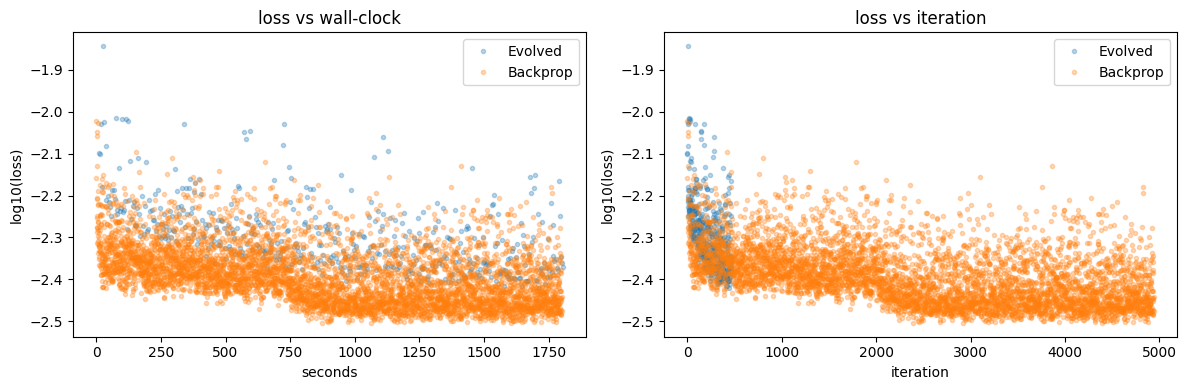

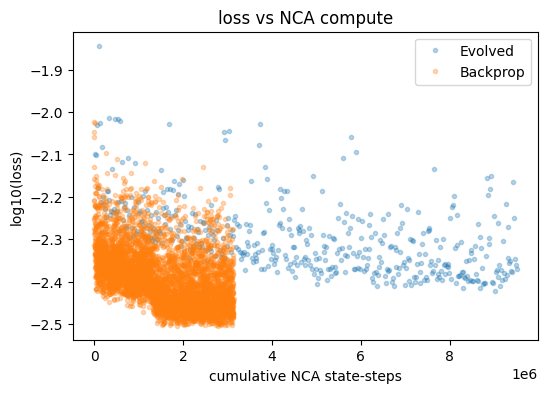

Target  |  Evolved  |  Backprop   (grown from the empty seed)


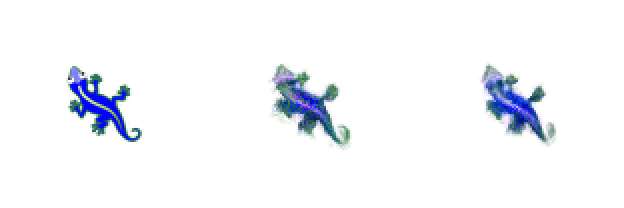

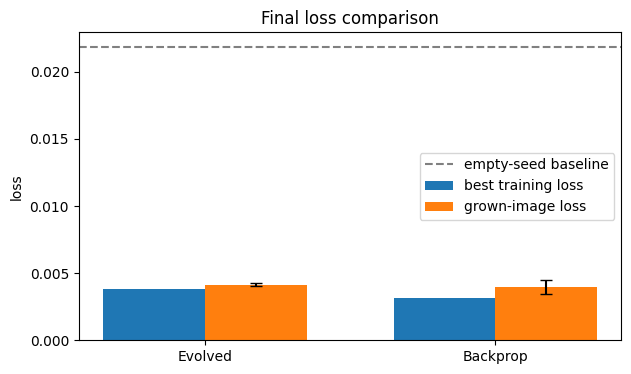

In [14]:
#@title Compare: Evolved vs Backprop
ev_grown, ev_grown_sd = grown_image_loss(M_evo)
bp_grown, bp_grown_sd = grown_image_loss(M_bp)

def time_to(loss_log, time_log, thr):
    for l, t in zip(loss_log, time_log):
        if l <= thr: return t
    return float('nan')

thr   = max(best_evo_loss, best_bp_loss)
t_evo = time_to(evo_loss_log, evo_time_log, thr)
t_bp  = time_to(bp_loss_log,  bp_time_log,  thr)

def row(label, a, b, fmt="{:>16.6f}"):
    print(f"{label:30s}" + fmt.format(a) + fmt.format(b))

print("=" * 62)
print(f"{'metric':30s}{'Evolved':>16s}{'Backprop':>16s}")
print("-" * 62)
row("iterations",            len(evo_loss_log), len(bp_loss_log), "{:>16d}")
row("wall-clock (s)",        evo_time_log[-1],  bp_time_log[-1],  "{:>16.0f}")
row("best training loss",    best_evo_loss,     best_bp_loss)
row("final-iter loss",       evo_loss_log[-1],  bp_loss_log[-1])
row("grown-image loss",      ev_grown,          bp_grown)
row("grown-image loss std",  ev_grown_sd,       bp_grown_sd)
row("NCA state-steps",       evo_steps_log[-1], bp_steps_log[-1], "{:>16.3e}")
row(f"sec to reach {thr:.4f}", t_evo,           t_bp,             "{:>16.1f}")
print("-" * 62)
print(f"{'baseline loss0 (empty seed)':30s}{loss0:>16.6f}")
print("=" * 62)

target_np = to_rgb(pad_target).numpy()
ev_grown_img = to_rgb(render_growth(M_evo, seed, RENDER_STEPS)[0][0]).numpy()
bp_grown_img = to_rgb(render_growth(M_bp, seed, RENDER_STEPS)[0][0]).numpy()

ev_ssim, ev_lpips, ev_fourier = compute_all_metrics(target_np, ev_grown_img)
bp_ssim, bp_lpips, bp_fourier = compute_all_metrics(target_np, bp_grown_img)

print("\n===== ADDITIONAL METRICS (against target image) =====")
print(f"{'Method':16s} {'SSIM':>8s} {'LPIPS':>8s} {'Fourier diff':>12s}")
print(f"{'Evolved':16s} {ev_ssim:8.6f} {ev_lpips:8.6f} {ev_fourier:12.6f}")
print(f"{'Backprop':16s} {bp_ssim:8.6f} {bp_lpips:8.6f} {bp_fourier:12.6f}")

pl.figure(figsize=(12, 4))
pl.subplot(1, 2, 1)
pl.title('loss vs wall-clock'); pl.xlabel('seconds'); pl.ylabel('log10(loss)')
pl.plot(evo_time_log, np.log10(evo_loss_log), '.', alpha=.3, label='Evolved')
pl.plot(bp_time_log,  np.log10(bp_loss_log),  '.', alpha=.3, label='Backprop')
pl.legend()
pl.subplot(1, 2, 2)
pl.title('loss vs iteration'); pl.xlabel('iteration'); pl.ylabel('log10(loss)')
pl.plot(np.log10(evo_loss_log), '.', alpha=.3, label='Evolved')
pl.plot(np.log10(bp_loss_log),  '.', alpha=.3, label='Backprop')
pl.legend(); pl.tight_layout(); pl.show()

pl.figure(figsize=(6, 4))
pl.title('loss vs NCA compute'); pl.xlabel('cumulative NCA state-steps'); pl.ylabel('log10(loss)')
pl.plot(evo_steps_log, np.log10(evo_loss_log), '.', alpha=.3, label='Evolved')
pl.plot(bp_steps_log,  np.log10(bp_loss_log),  '.', alpha=.3, label='Backprop')
pl.legend(); pl.show()

CAP = [0, 20, 40, 60, 80, 100, RENDER_STEPS]
evo_final, evo_frames = render_growth(M_evo, seed, RENDER_STEPS, CAP)
bp_final,  bp_frames  = render_growth(M_bp,  seed, RENDER_STEPS, CAP)

trio = np.hstack([to_rgb(pad_target).numpy(),
                  to_rgb(evo_final[0]).numpy(),
                  to_rgb(bp_final[0]).numpy()])
print('Target  |  Evolved  |  Backprop   (grown from the empty seed)')
imshow(zoom(trio, 2), fmt='png')

pl.figure(figsize=(7, 4))
labels = ['Evolved', 'Backprop']
xpos   = np.arange(len(labels)); bw = 0.35
pl.bar(xpos - bw / 2, [best_evo_loss, best_bp_loss], bw, label='best training loss')
pl.bar(xpos + bw / 2, [ev_grown, bp_grown], bw, yerr=[ev_grown_sd, bp_grown_sd],
       capsize=4, label='grown-image loss')
pl.axhline(loss0, ls='--', c='gray', label='empty-seed baseline')
pl.xticks(xpos, labels); pl.ylabel('loss'); pl.title('Final loss comparison')
pl.legend(); pl.show()


In [15]:
#@title Final perturbation matrices: Gradient vs CMA-ES
np.set_printoptions(precision=3, suppress=True, linewidth=200)

print("Gradient (backprop) final perturbation matrix  M_bp  (16x16):")
print(M_bp)
print(f"\n||M_bp - I||_F = {np.linalg.norm(M_bp - np.eye(16)):.4f}")

print("\n" + "=" * 70 + "\n")

print("CMA-ES (evolved) final perturbation matrix  M_evo  (16x16):")
print(M_evo)
print(f"\n||M_evo - I||_F = {np.linalg.norm(M_evo - np.eye(16)):.4f}")


Gradient (backprop) final perturbation matrix  M_bp  (16x16):
[[ 0.912  0.02   0.074 -0.025  0.028  0.013  0.014 -0.002  0.011  0.002  0.007  0.013  0.001 -0.009 -0.006  0.008]
 [ 0.02   0.872  0.131 -0.033  0.025  0.007  0.033 -0.002  0.026 -0.009  0.024  0.024  0.014 -0.037  0.008  0.029]
 [ 0.074  0.131  0.706  0.081 -0.051 -0.039 -0.071 -0.008 -0.046  0.025 -0.033 -0.077 -0.029  0.066 -0.025 -0.061]
 [-0.025 -0.033  0.081  0.97   0.003  0.012  0.021 -0.003  0.002 -0.007  0.017  0.023  0.004 -0.02   0.006  0.017]
 [ 0.028  0.025 -0.051  0.003  0.927 -0.027 -0.015 -0.004 -0.002  0.016 -0.006 -0.018  0.017  0.022  0.002 -0.027]
 [ 0.013  0.007 -0.039  0.012 -0.027  1.019  0.001 -0.016 -0.008  0.015 -0.003 -0.002  0.011  0.007  0.004 -0.012]
 [ 0.014  0.033 -0.071  0.021 -0.015  0.001  1.    -0.005  0.002  0.006 -0.015 -0.002 -0.023  0.002  0.009  0.005]
 [-0.002 -0.002 -0.008 -0.003 -0.004 -0.016 -0.005  0.994  0.006 -0.011  0.008 -0.008 -0.013  0.014 -0.015  0.006]
 [ 0.011  0.026 -0

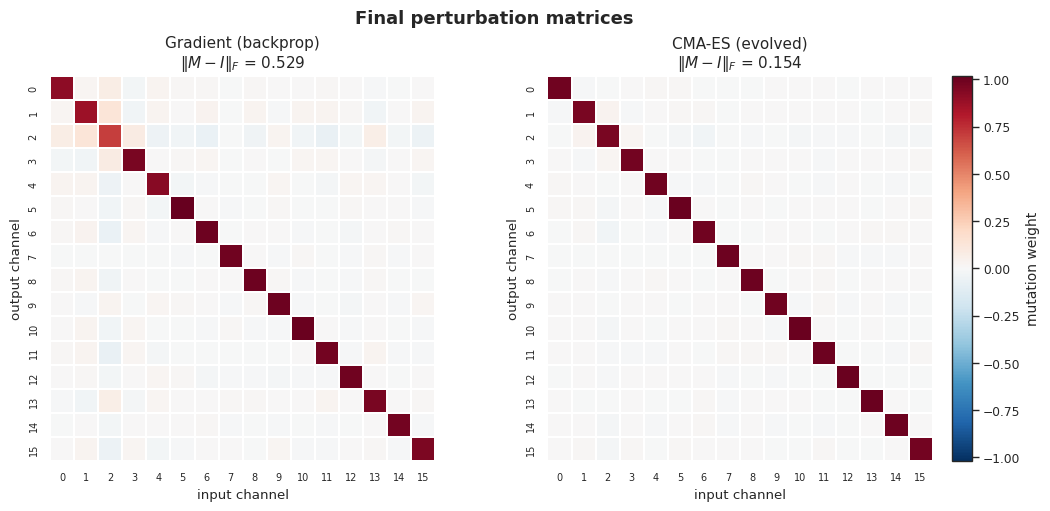

In [16]:
#@title Perturbation-matrix heatmaps: Gradient vs CMA-ES
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", context="paper")

vmax = float(np.max(np.abs([M_bp, M_evo])))
vmin = -vmax

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
for ax, M, title in zip(axes, [M_bp, M_evo],
                        ["Gradient (backprop)", "CMA-ES (evolved)"]):
    sns.heatmap(M, ax=ax, cmap="RdBu_r", vmin=vmin, vmax=vmax, center=0,
                square=True, cbar=False, linewidths=0.3, linecolor="white",
                xticklabels=range(16), yticklabels=range(16))
    ax.set_title(f"{title}\n$\\|M-I\\|_F$ = {np.linalg.norm(M - np.eye(16)):.3f}",
                 fontsize=11)
    ax.set_xlabel("input channel")
    ax.set_ylabel("output channel")
    ax.tick_params(labelsize=7)

cbar = fig.colorbar(axes[0].collections[0], ax=axes, fraction=0.046, pad=0.02,
                    location="right")
cbar.set_label("mutation weight", fontsize=10)

fig.suptitle("Final perturbation matrices", fontsize=13, fontweight="bold")
plt.show()
